# ПРАКТИКУМ: ОБУЧЕНИЕ БЕЗ УЧИТЕЛЯ

    Практические задания для самостоятельной работы

     Цели практикума:,
    "- Освоить основные алгоритмы кластеризации",
    "- Научиться применять методы снижения размерности",
    "- Освоить техники обнаружения аномалий",
    "- Развить навыки интерпретации результатов",
    "- Понять критерии оценки качества",
    Структура работы:

1. Подготовка данных и EDA
2. Кластеризация (K-Means, Hierarchical, DBSCAN)
3. Снижение размерности (PCA, t-SNE)
4. Обнаружение аномалий
5. Анализ и интерпретация результатов


## БЛОК 1: Импорт библиотек и настройка окружения

In [5]:
# Основные библиотеки для работы с данными
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Настройка визуализации
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("Основные библиотеки загружены")

Основные библиотеки загружены


In [6]:
# Библиотеки машинного обучения
from sklearn.datasets import make_blobs, make_circles, make_moons, load_wine, load_breast_cancer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# Алгоритмы кластеризации
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.mixture import GaussianMixture

# Снижение размерности
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Обнаружение аномалий
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

# Метрики качества
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

# Иерархическая кластеризация
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist

print("Библиотеки машинного обучения загружены")

Библиотеки машинного обучения загружены


## БЛОК 2: Подготовка и исследование данных

In [ ]:
# ЗАДАЧА 2.1: Загрузка и первичный анализ данных


from sklearn.datasets import load_wine
import pandas as pd

wine = load_wine()
df = pd.DataFrame(data=wine.data, columns = wine.feature_names)
df["target"] = wine.target
print("Первые 5 строк: ")
print(df.head())

print("Кол-во обьектов и признаков: ", df.shape)
print("\Названия признаков:")
print(wine.feature_names)

print("Кол-во классов в целевой переменной: ", len(wine.target_names))
print("Названия классов: ", wine.target_names)

print("Проверка на пропущенные значения: ")
print(df.isnull().sum())

print("Информация о датафрейме: ")
print(df.info())

print("Основная статистика по признакам: ")
print(df.describe())


Первые 5 строк: 
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  tar

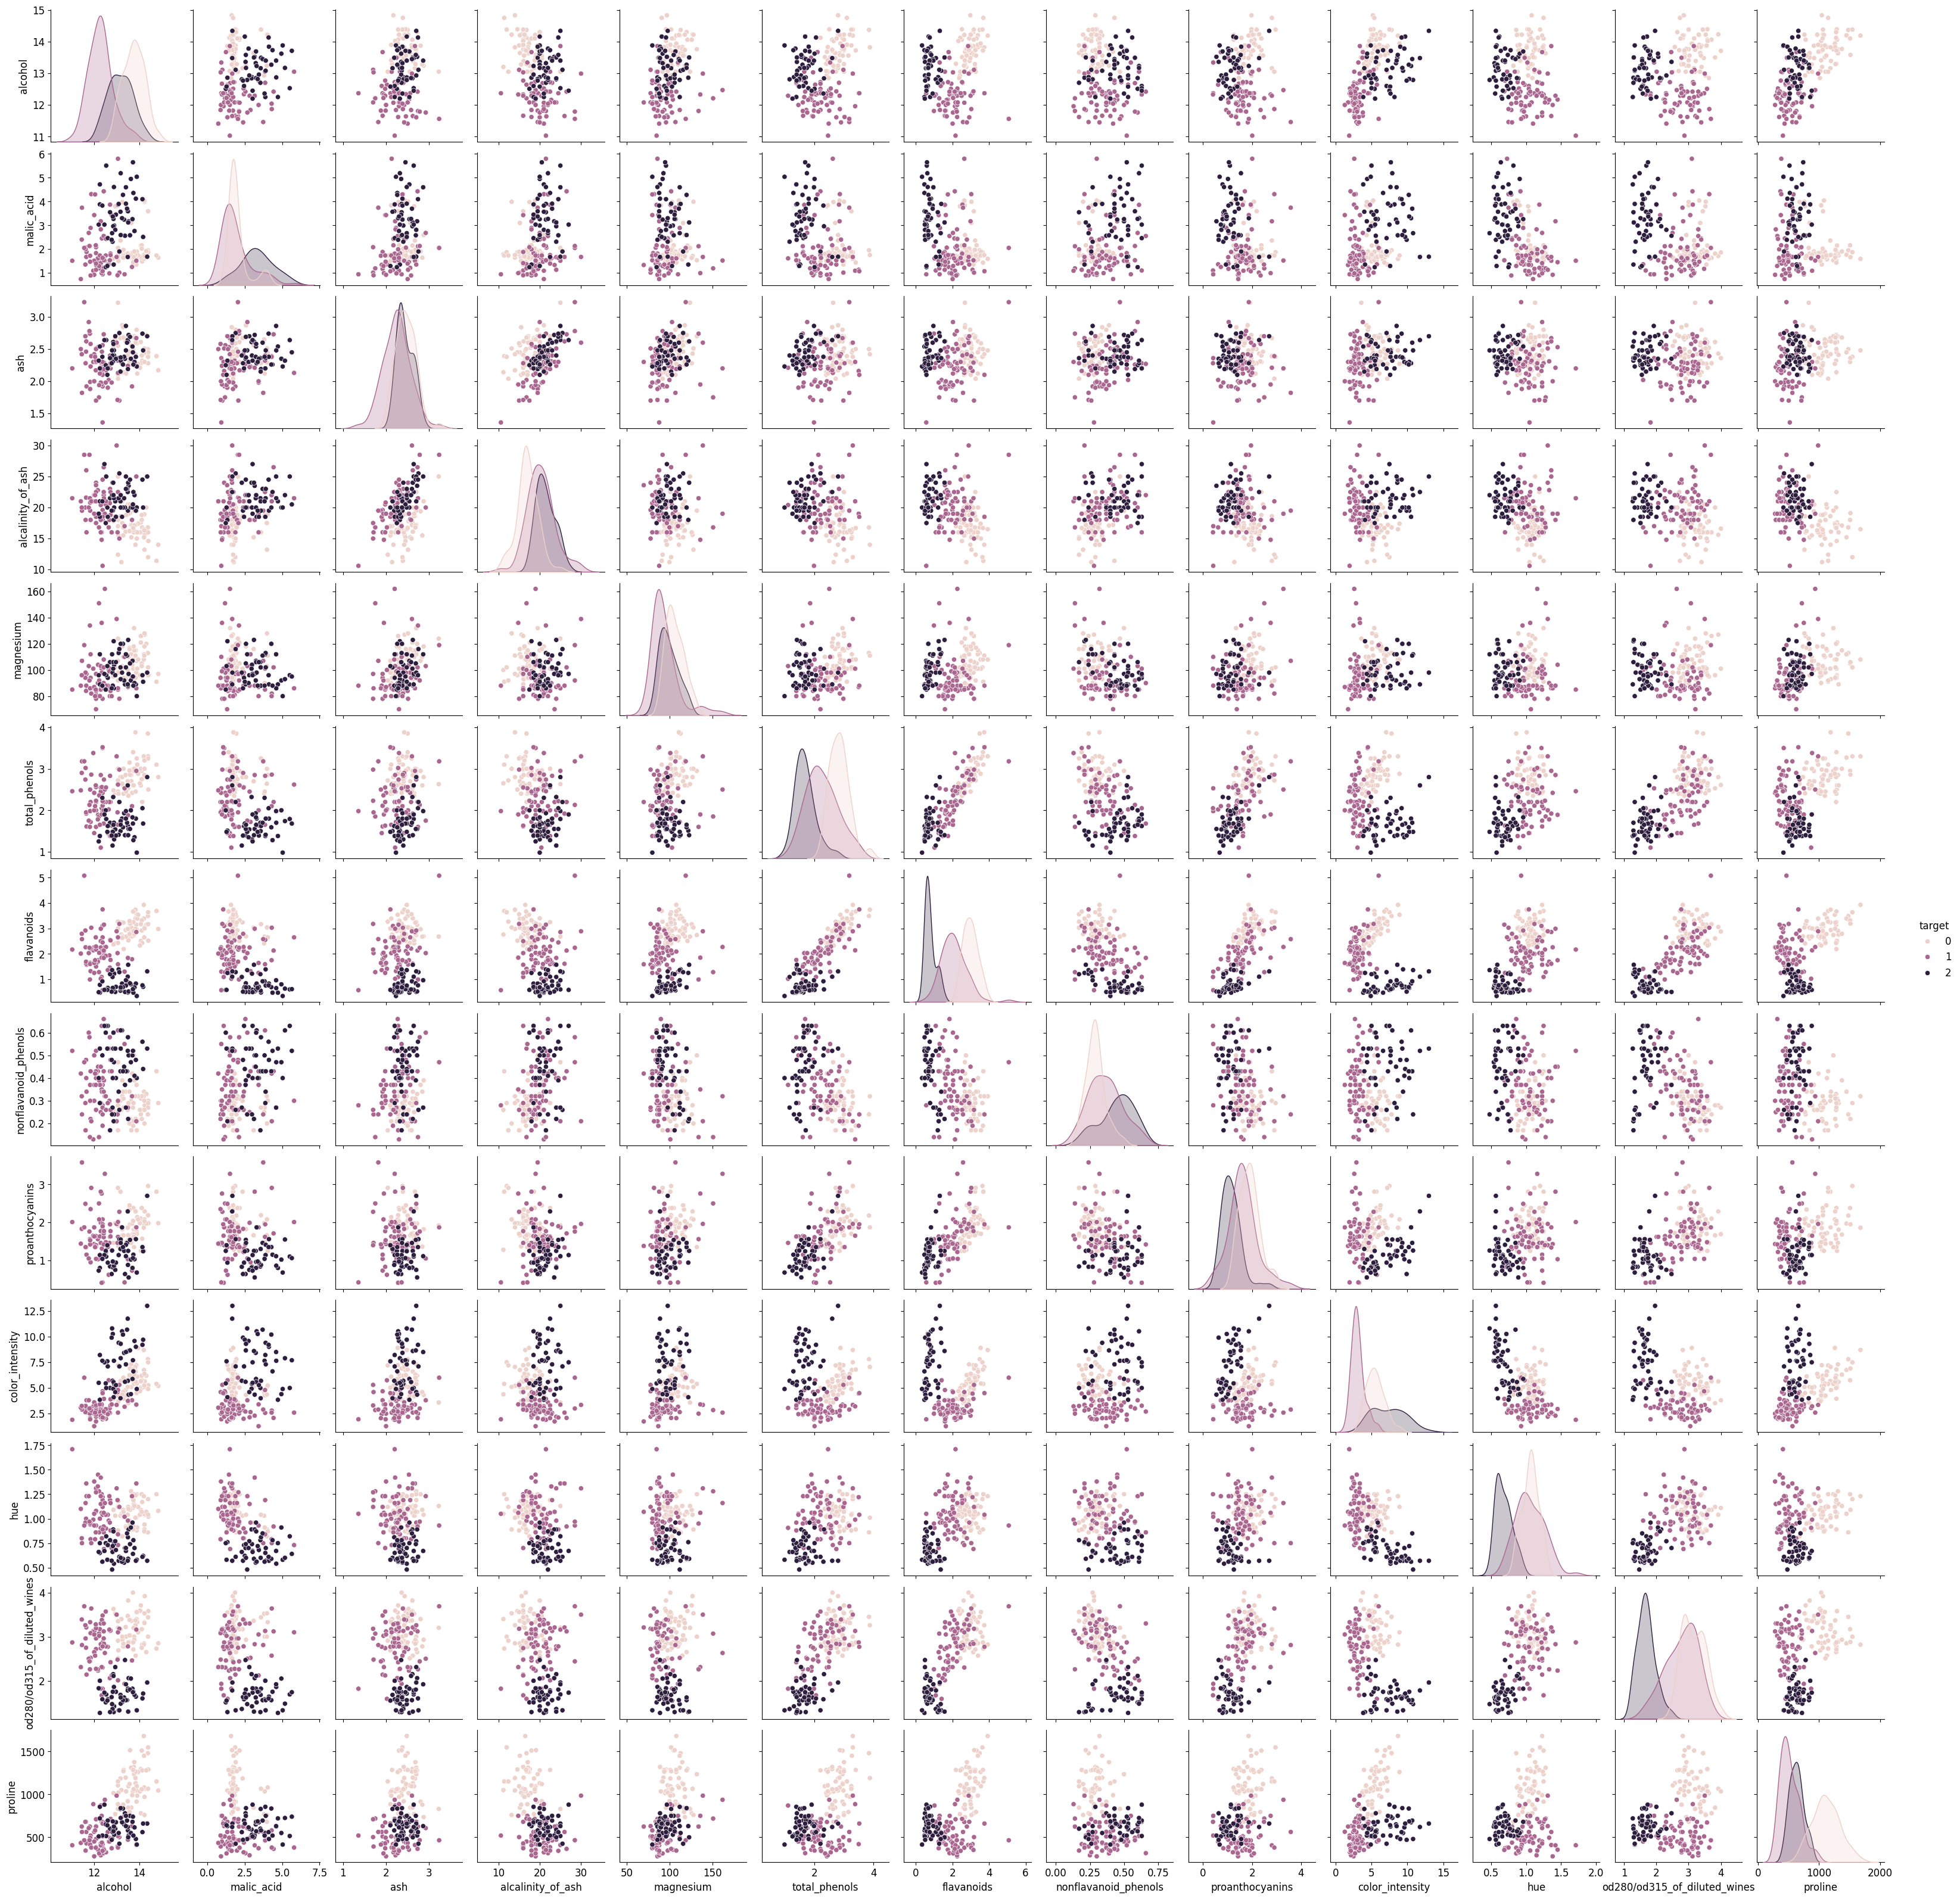

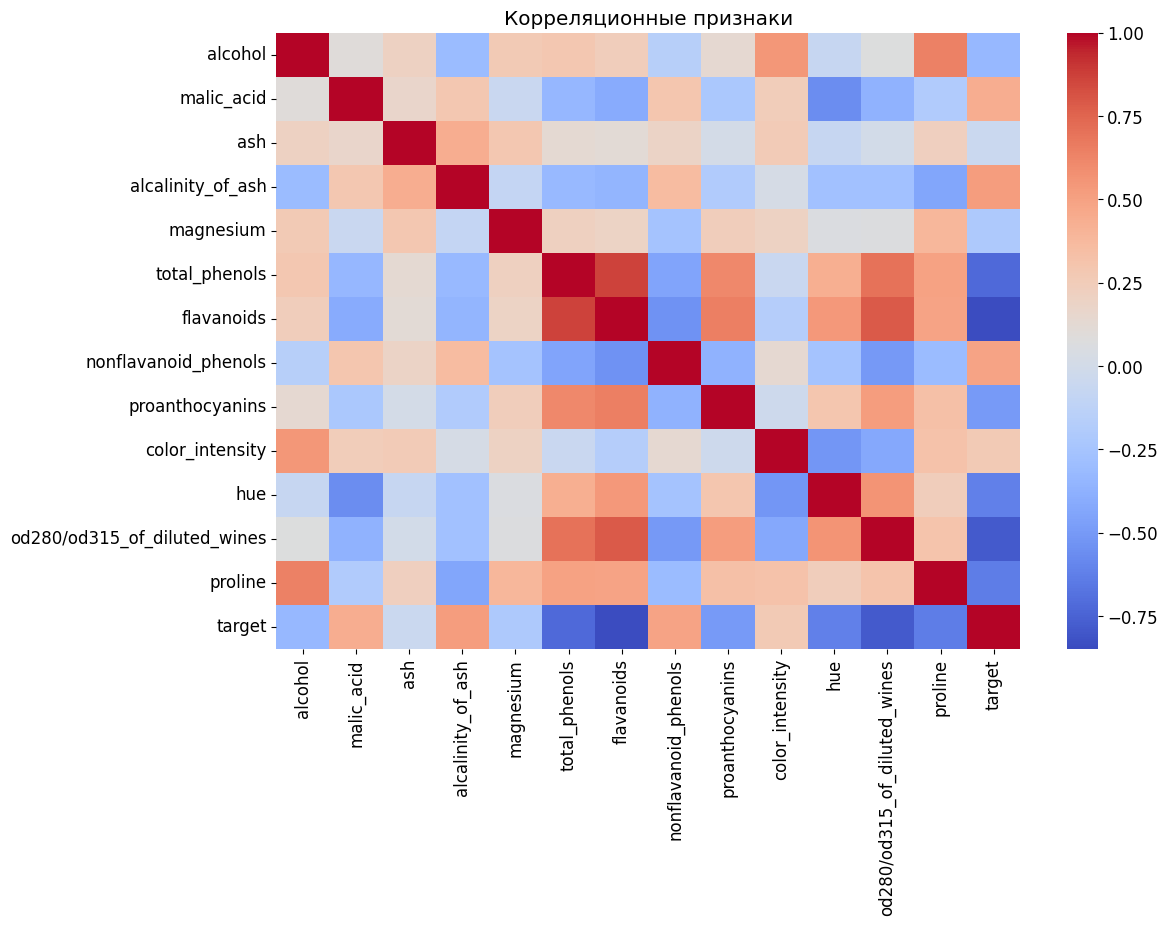

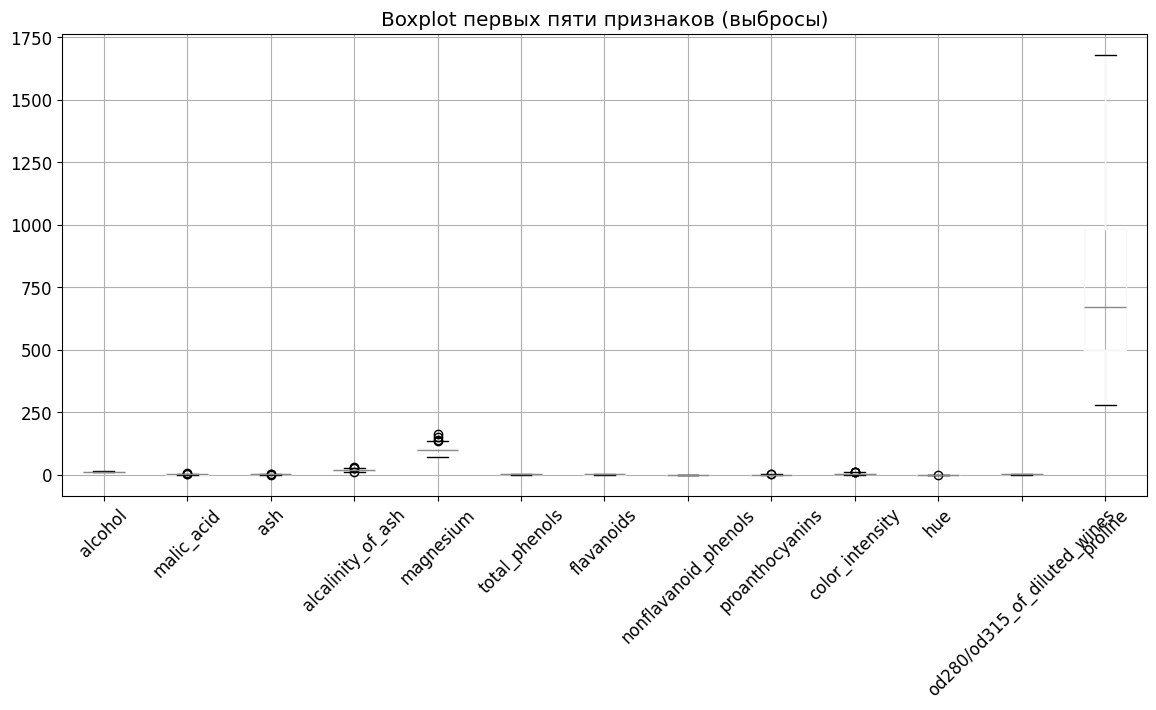

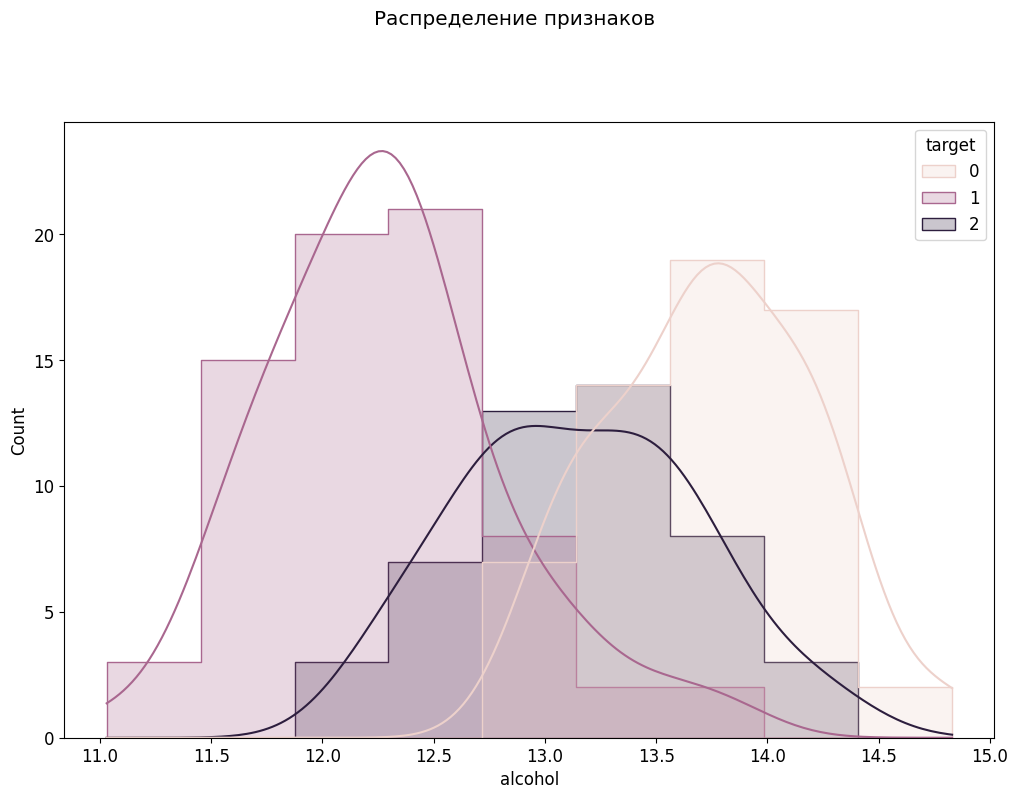

In [9]:
# ЗАДАЧА 2.2: Визуализация данных

#1
sns.pairplot(df, hue = "target", diag_kind = "kde")
plt.show()

#2 
plt.figure(figsize = (12, 8))
sns.heatmap(df.corr(), annot = False, cmap = "coolwarm")
plt.title("Корреляционные признаки")
plt.show()

#3
plt.figure(figsize=(14, 6))
df.drop(columns = ["target"]).boxplot(rot=45)
plt.title("Boxplot первых пяти признаков (выбросы)")
plt.show()

#4 
sns.histplot(data=df, x="alcohol", hue="target", kde=True, element="step")
plt.suptitle("Распределение признаков", y=1.02)
plt.show()



In [ ]:
# ЗАДАЧА 2.3: Предобработка данных

from sklearn.preprocessing import StandardScaler
X_original = df.drop(columns=["target"])
y_true = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_original)

print("Сред. значения после стандартизации: ")
print(X_scaled.mean(axis=0))

print("Стандартные отклонения после стандартизации")
print(X_scaled.std(axis=0))

print("Размерность X_scaled: ", X_scaled.shape)
print("Размерность X_original: ", X_original.shape)
print("Размерность y_true:", y_true.shape)


Сред. значения после стандартизации: 
[ 7.84141790e-15  2.44498554e-16 -4.05917497e-15 -7.11041712e-17
 -2.49488320e-17 -1.95536471e-16  9.44313292e-16 -4.17892936e-16
 -1.54059038e-15 -4.12903170e-16  1.39838203e-15  2.12688793e-15
 -6.98567296e-17]
Стандартные отклонения после стандартизации
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Размерность X_scaled:  (178, 13)
Размерность X_original:  (178, 13)
Размерность y_true: (178,)


## БЛОК 3: Кластеризация - K-Means

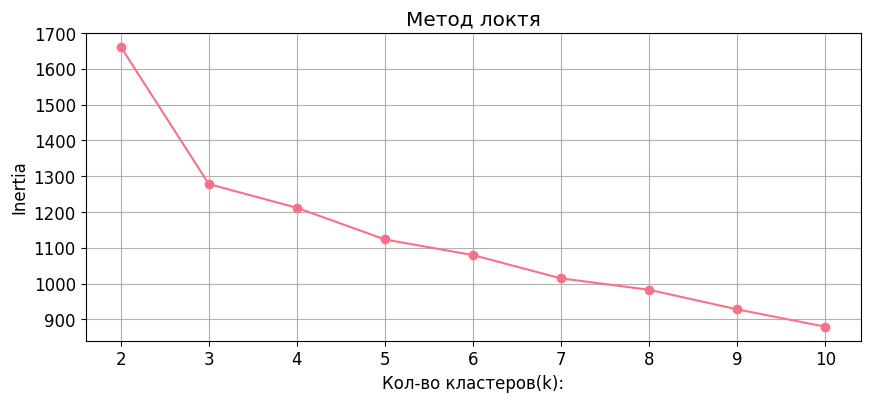

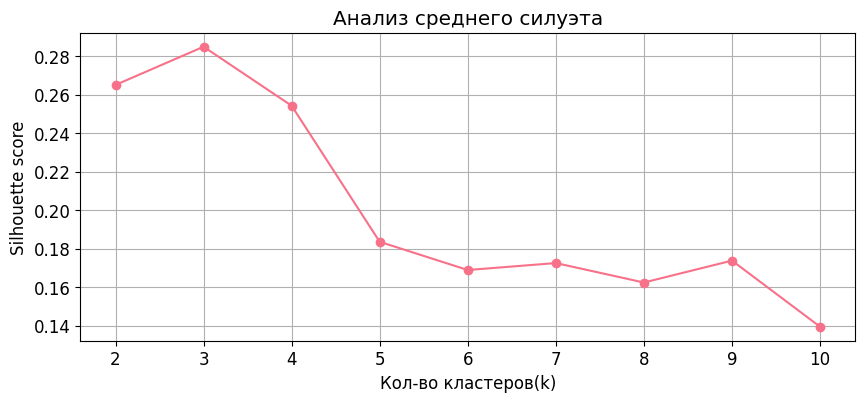

In [ ]:
# ЗАДАЧА 3.1: Определение оптимального количества кластеров

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

inertia = []
silhouette_values = []
k_values = range(2,11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state = 42)
    labels = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(10, 4))
plt.plot(k_values, inertia, marker = 'o')
plt.title("Метод локтя")
plt.xlabel("Кол-во кластеров(k):")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()

plt.figure(figsize =(10,4))
plt.plot(k_values, silhouette_values, marker = 'o')
plt.title("Анализ среднего силуэта")
plt.xlabel("Кол-во кластеров(k)")
plt.ylabel("Silhouette score")
plt.grid(True)
plt.show()


In [15]:
# ЗАДАЧА 3.2: Применение K-Means с оптимальным k
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score
)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state = 42)

kmeans.fit(X_scaled)
labels = kmeans.labels_

sil = silhouette_score(X_scaled, labels)
ch = calinski_harabasz_score(X_scaled, labels)
db = davies_bouldin_score(X_scaled, labels)
ari = adjusted_rand_score(y_true, labels)


print(f"Silhouette Score: {sil:.4f}")
print(f"Calinski-Harabasz Index: {ch:.2f}")
print(f"Davies-Bouldin Index: {db:.4f}")
print(f"Adjusted Rand Index (сравнение с истинными метками): {ari:.4f}")

Silhouette Score: 0.2849
Calinski-Harabasz Index: 70.94
Davies-Bouldin Index: 1.3892
Adjusted Rand Index (сравнение с истинными метками): 0.8975


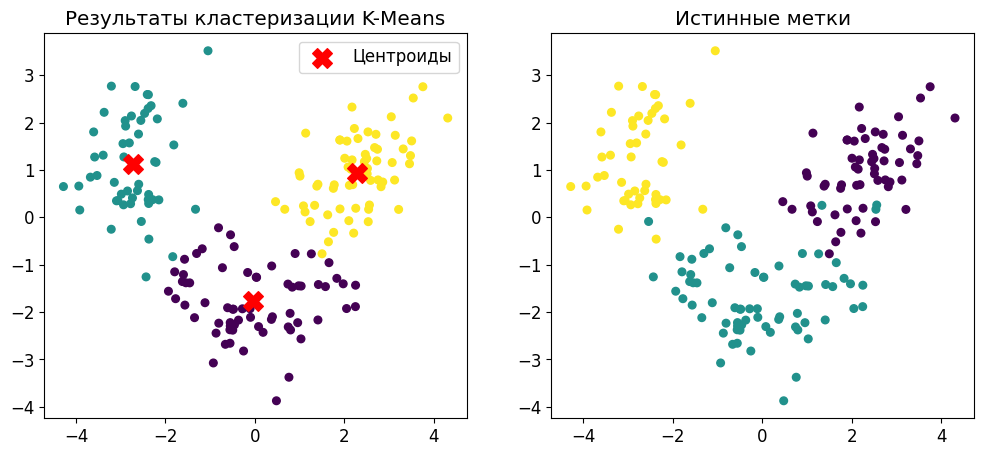

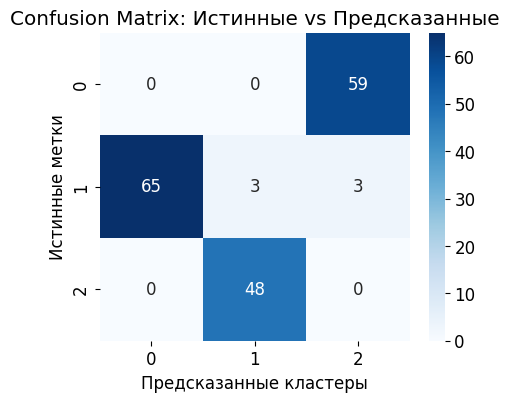

In [16]:
# ЗАДАЧА 3.3: Визуализация результатов K-Means

from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_, cmap='viridis', s=30)
plt.scatter(pca.transform(kmeans.cluster_centers_)[:, 0],
            pca.transform(kmeans.cluster_centers_)[:, 1],
            c='red', marker='X', s=200, label='Центроиды')
plt.title('Результаты кластеризации K-Means')
plt.legend()


plt.subplot(1, 2, 2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, cmap='viridis', s=30)
plt.title('Истинные метки')

plt.show()


cm = confusion_matrix(y_true, kmeans.labels_)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Истинные vs Предсказанные')
plt.xlabel('Предсказанные кластеры')
plt.ylabel('Истинные метки')
plt.show()

## БЛОК 4: Иерархическая кластеризация

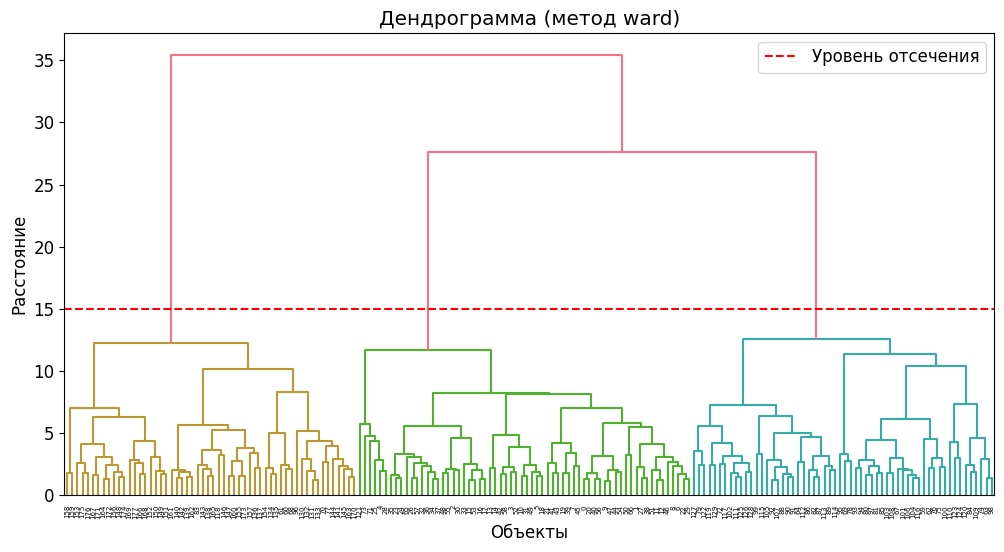

In [17]:
# ЗАДАЧА 4.1: Построение дендрограммы


from scipy.cluster.hierarchy import linkage, dendrogram

Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(12, 6))
dendrogram(Z)
plt.title("Дендрограмма (метод ward)")
plt.xlabel("Объекты")
plt.ylabel("Расстояние")


plt.axhline(y=15, color='r', linestyle='--', label='Уровень отсечения')
plt.legend()
plt.show()


In [ ]:
# ЗАДАЧА 4.2: Сравнение методов связывания

from sklearn.cluster import AgglomerativeClustering

linkage_methods = ['ward', 'complete', 'average', 'single']

results = []

#кластеризация
for method in linkage_methods:
    model = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = model.fit_predict(X_scaled)
    
    sil = silhouette_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ar = adjusted_rand_score(y_true, labels)
    
    results.append({
        'Метод': method,
        'Silhouette': sil,
        'Calinski-Harabasz': ch,
        'Davies-Bouldin': db,
        'Adjusted Rand': ari
    })

results_df = pd.DataFrame(results)
print("Результаты сравнения методов связывания:")
print(results_df)

best_method = results_df.loc[results_df['Silhouette'].idxmax(), 'Метод']
print("\nЛучший метод по метрике Silhouette:", best_method)


Результаты сравнения методов связывания:
      Метод  Silhouette  Calinski-Harabasz  Davies-Bouldin  Adjusted Rand
0      ward    0.277444          67.647468        1.418592       0.897495
1  complete    0.203787          48.989830        1.896096       0.897495
2   average    0.157525           4.031439        1.029890       0.897495
3    single    0.182738           4.061665        0.910518       0.897495

Лучший метод по метрике Silhouette: ward


## БЛОК 5: DBSCAN - плотностная кластеризация

min_samples = 14


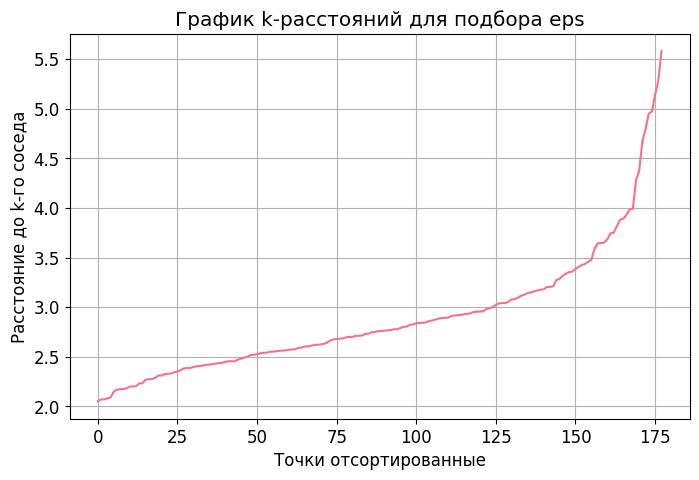

In [20]:
# ЗАДАЧА 5.1: Подбор параметров для DBSCAN


from sklearn.neighbors import NearestNeighbors


min_samples = X_scaled.shape[1] + 1
print("min_samples =", min_samples)

neigh = NearestNeighbors(n_neighbors=min_samples)
nbrs = neigh.fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 5))
plt.plot(k_distances)
plt.title("График k-расстояний для подбора eps")
plt.xlabel("Точки отсортированные")
plt.ylabel("Расстояние до k-го соседа")
plt.grid(True)
plt.show()

In [27]:
# ЗАДАЧА 5.2: Применение DBSCAN
from sklearn.cluster import DBSCAN

eps_value = 0.8 
dbscan = DBSCAN(eps=eps_value, min_samples = min_samples)
labels_db = dbscan.fit_predict(X_scaled)

n_clusters = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise = np.sum(labels_db == -1)
print(f"Кластеров найдено: {n_clusters}, шумовых точек: {n_noise}")




Кластеров найдено: 0, шумовых точек: 178


## БЛОК 6: Снижение размерности

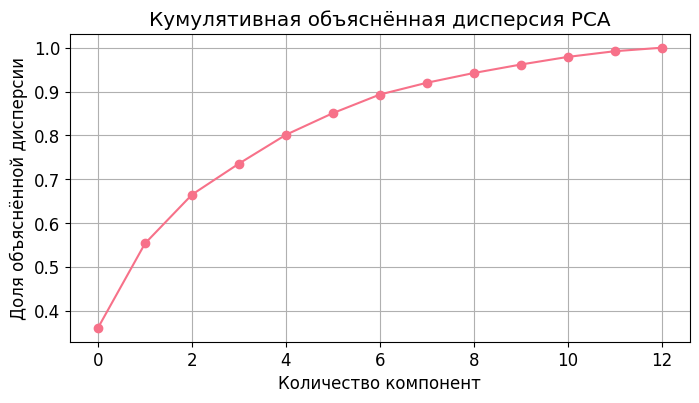

Количество компонент для объяснения 95% дисперсии: 10

Loadings (веса признаков в компонентах):
                        PC1       PC2       PC3       PC4       PC5       PC6  \
alcohol            0.144329  0.483652 -0.207383 -0.017856 -0.265664  0.213539   
malic_acid        -0.245188  0.224931  0.089013  0.536890  0.035214  0.536814   
ash               -0.002051  0.316069  0.626224 -0.214176 -0.143025  0.154475   
alcalinity_of_ash -0.239320 -0.010591  0.612080  0.060859  0.066103 -0.100825   
magnesium          0.141992  0.299634  0.130757 -0.351797  0.727049  0.038144   

                        PC7       PC8       PC9      PC10      PC11      PC12  \
alcohol           -0.056396  0.396139 -0.508619  0.211605 -0.225917 -0.266286   
malic_acid         0.420524  0.065827  0.075283 -0.309080  0.076486  0.121696   
ash               -0.149171 -0.170260  0.307694 -0.027125 -0.498691 -0.049622   
alcalinity_of_ash -0.286969  0.427970 -0.200449  0.052799  0.479314 -0.055743   
magnesium   

In [ ]:
# ЗАДАЧА 6.1: Анализ главных компонент (PCA)

pca = PCA()
X_pca_full = pca.fit_transform(X_scaled)


plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.title("объяснённая дисперсия PCA")
plt.xlabel("Кол-во компонент")
plt.ylabel("Доля объяснённой дисперсии")
plt.grid(True)
plt.show()

cum_var = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cum_var >= 0.95) + 1
print(f"Кол-во компонент для объяснения 95% дисперсии: {n_components_95}")

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(len(pca.components_))],
    index=df.columns[:-1]
)
print("\nLoadings (веса признаков в компонентах):")
print(loadings.head())

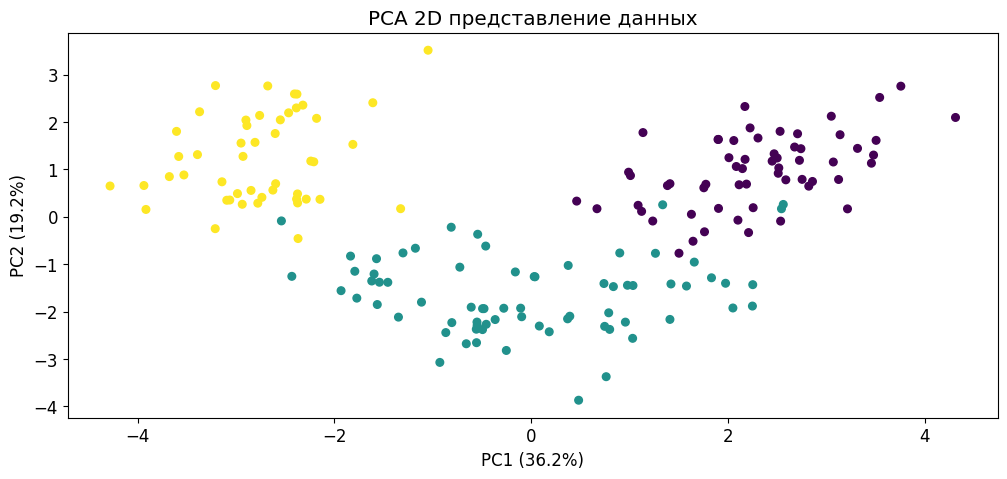

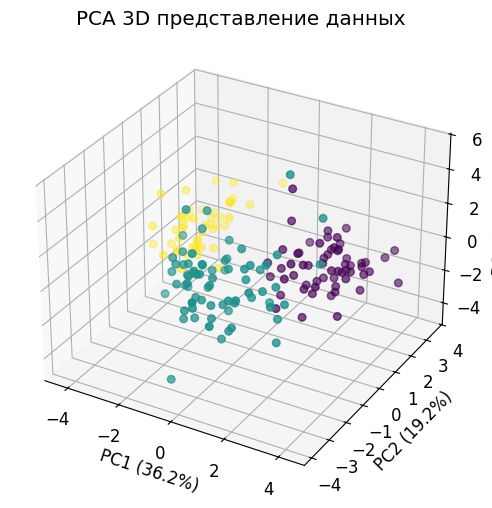

In [36]:
# ЗАДАЧА 6.2: Визуализация в пространстве главных компонент
from mpl_toolkits.mplot3d import Axes3D

pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

#2D
plt.figure(figsize=(12, 5))
plt.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y_true, cmap='viridis', s=30)
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
plt.title("PCA 2D представление данных")
plt.show()

#3D
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(
    X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
    c=y_true, cmap='viridis', s=30
)
ax.set_xlabel(f"PC1 ({pca_3d.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca_3d.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_zlabel(f"PC3 ({pca_3d.explained_variance_ratio_[2]*100:.1f}%)")
ax.set_title("PCA 3D представление данных")
plt.show()

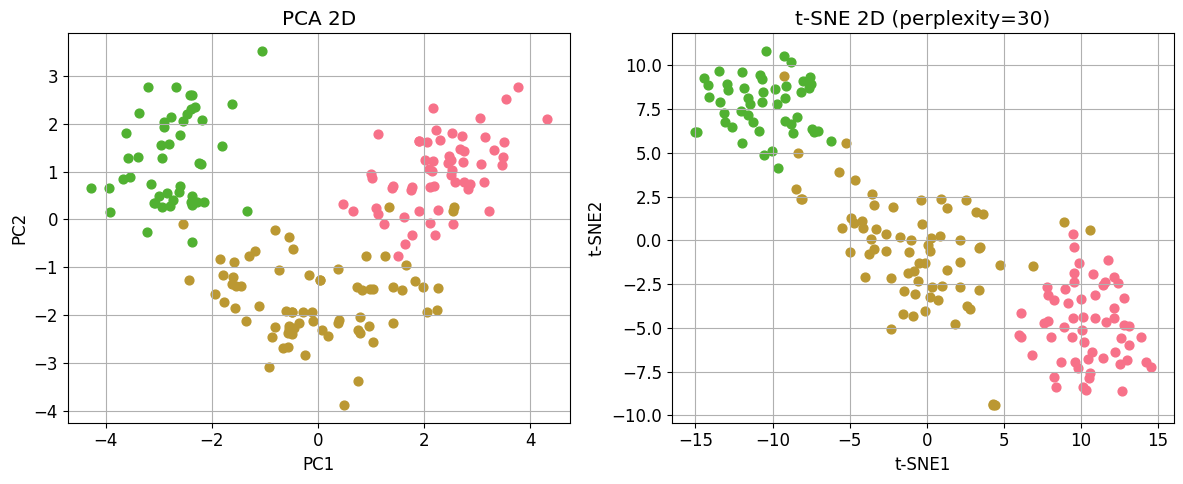

In [39]:
# ЗАДАЧА 6.3: Сравнение с t-SNE


from sklearn.manifold import TSNE


tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)


plt.figure(figsize=(12,5))

# PCA
plt.subplot(1,2,1)
for target in range(len(wine.target_names)):
    plt.scatter(X_pca_2d[y_true==target,0], X_pca_2d[y_true==target,1],
                label=wine.target_names[target], s=40)
plt.title("PCA 2D")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)

# t-SNE
plt.subplot(1,2,2)
for target in range(len(wine.target_names)):
    plt.scatter(X_tsne[y_true==target,0], X_tsne[y_true==target,1],
                label=wine.target_names[target], s=40)
plt.title("t-SNE 2D (perplexity=30)")
plt.xlabel("t-SNE1")
plt.ylabel("t-SNE2")
plt.grid(True)

plt.tight_layout()
plt.show()

## БЛОК 7: Обнаружение аномалий

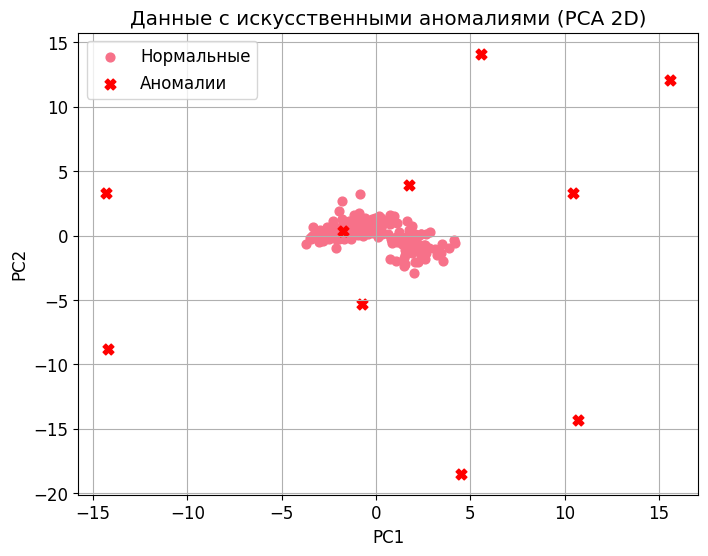

In [40]:
# ЗАДАЧА 7.1: Подготовка данных с аномалиями

X_with_outliers = X_scaled.copy()
y_outliers = np.ones(X_scaled.shape[0])


n_outliers = 10
np.random.seed(42)

outliers = np.random.uniform(low=-10, high=10, size=(n_outliers, X_scaled.shape[1]))


X_with_outliers = np.vstack([X_with_outliers, outliers])
y_outliers = np.hstack([y_outliers, -1*np.ones(n_outliers)])


pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_with_outliers)


plt.figure(figsize=(8,6))
plt.scatter(X_pca_vis[y_outliers==1,0], X_pca_vis[y_outliers==1,1], label='Нормальные', s=40)
plt.scatter(X_pca_vis[y_outliers==-1,0], X_pca_vis[y_outliers==-1,1], label='Аномалии', s=60, color='red', marker='X')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Данные с искусственными аномалиями (PCA 2D)")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# ЗАДАЧА 7.2: Применение алгоритмов обнаружения аномалий
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import accuracy_score, precision_score, recall_score

contamination = np.mean(y_outliers == -1)


iso_forest = IsolationForest(contamination=contamination, random_state=42)
iso_pred = iso_forest.fit_predict(X_with_outliers)


oc_svm = OneClassSVM(nu=contamination, kernel='rbf', gamma='scale')
oc_pred = oc_svm.fit_predict(X_with_outliers)


lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination)
lof_pred = lof.fit_predict(X_with_outliers)


def evaluate(y_true, y_pred, method_name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, pos_label=-1)
    rec = recall_score(y_true, y_pred, pos_label=-1)
    print(f"{method_name}: Accuracy={acc:.2f}, Precision={prec:.2f}, Recall={rec:.2f}")


evaluate(y_outliers, iso_pred, "Isolation Forest")
evaluate(y_outliers, oc_pred, "One-Class SVM")
evaluate(y_outliers, lof_pred, "LOF")


Isolation Forest: Accuracy=1.00, Precision=1.00, Recall=1.00
One-Class SVM: Accuracy=0.96, Precision=0.60, Recall=0.60
LOF: Accuracy=1.00, Precision=1.00, Recall=1.00


## БЛОК 8: Комплексный анализ и интерпретация

                  Метод                   Параметры  Silhouette       ARI  \
0               K-Means                n_clusters=3    0.284859  0.897495   
1  Agglomerative (ward)  n_clusters=3, linkage=ward    0.277444  0.789933   
2                DBSCAN     eps=0.8, min_samples=14         NaN       NaN   

        NMI  Время (с)  
0  0.875894   0.002916  
1  0.786465   0.000000  
2       NaN   0.001472  


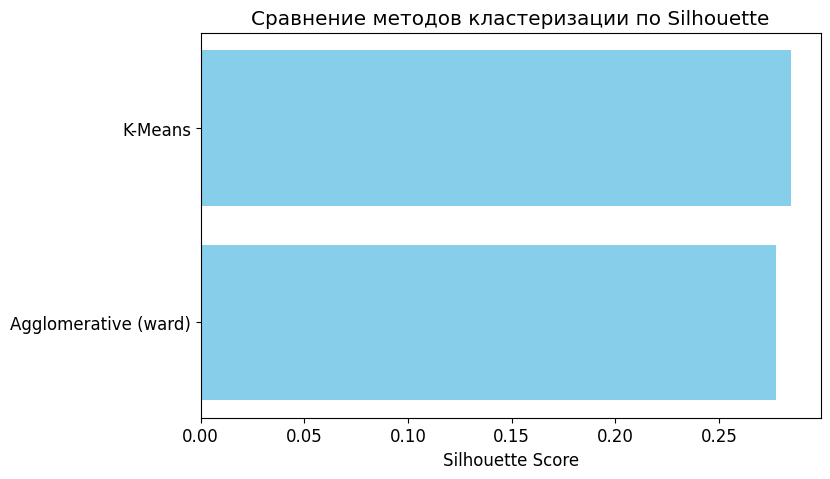

In [43]:
# ЗАДАЧА 8.1: Сравнение всех методов кластеризации
import time
from sklearn.metrics import normalized_mutual_info_score as nmi

methods = []

#K-Means
start = time.time()
kmeans = KMeans(n_clusters=3, random_state=42)
labels_km = kmeans.fit_predict(X_scaled)
end = time.time()
methods.append({
    'Метод': 'K-Means',
    'Параметры': 'n_clusters=3',
    'Silhouette': silhouette_score(X_scaled, labels_km),
    'ARI': adjusted_rand_score(y_true, labels_km),
    'NMI': nmi(y_true, labels_km),
    'Время (с)': end - start
})

#Agglomerative
start = time.time()
agglo = AgglomerativeClustering(n_clusters=3, linkage=best_method)
labels_agg = agglo.fit_predict(X_scaled)
end = time.time()
methods.append({
    'Метод': f'Agglomerative ({best_method})',
    'Параметры': f'n_clusters=3, linkage={best_method}',
    'Silhouette': silhouette_score(X_scaled, labels_agg),
    'ARI': adjusted_rand_score(y_true, labels_agg),
    'NMI': nmi(y_true, labels_agg),
    'Время (с)': end - start
})

#DBSCAN
start = time.time()
dbscan = DBSCAN(eps=0.8, min_samples=X_scaled.shape[1]+1)
labels_db = dbscan.fit_predict(X_scaled)
end = time.time()

mask = labels_db != -1
methods.append({
    'Метод': 'DBSCAN',
    'Параметры': f'eps=0.8, min_samples={X_scaled.shape[1]+1}',
    'Silhouette': silhouette_score(X_scaled[mask], labels_db[mask]) if len(set(labels_db[mask]))>1 else None,
    'ARI': adjusted_rand_score(y_true[mask], labels_db[mask]) if len(set(labels_db[mask]))>1 else None,
    'NMI': nmi(y_true[mask], labels_db[mask]) if len(set(labels_db[mask]))>1 else None,
    'Время (с)': end - start
})

results_df = pd.DataFrame(methods)
results_df = results_df.sort_values(by='Silhouette', ascending=False)
print(results_df)

plt.figure(figsize=(8,5))
plt.barh(results_df['Метод'], results_df['Silhouette'], color='skyblue')
plt.xlabel('Silhouette Score')
plt.title('Сравнение методов кластеризации по Silhouette')
plt.gca().invert_yaxis()
plt.show()

Сред. значения признаков по кластерам:
           alcohol  malic_acid       ash  alcalinity_of_ash   magnesium  \
cluster                                                                   
0        12.250923    1.897385  2.231231          20.063077   92.738462   
1        13.134118    3.307255  2.417647          21.241176   98.666667   
2        13.676774    1.997903  2.466290          17.462903  107.967742   

         total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
cluster                                                                     
0             2.247692    2.050000              0.357692         1.624154   
1             1.683922    0.818824              0.451961         1.145882   
2             2.847581    3.003226              0.292097         1.922097   

         color_intensity       hue  od280/od315_of_diluted_wines      proline  \
cluster                                                                         
0               2.973077  1.062708   

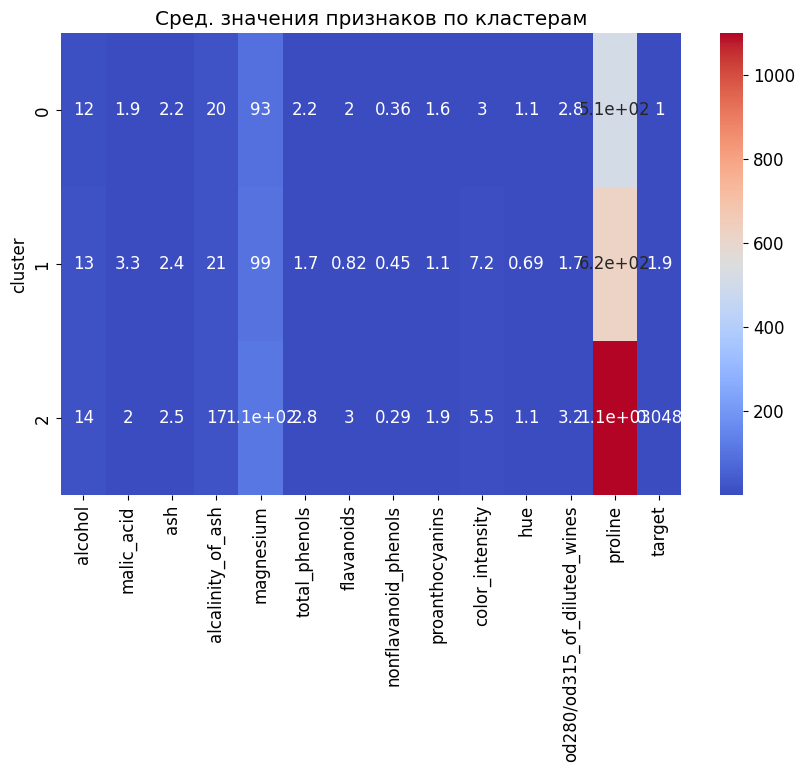

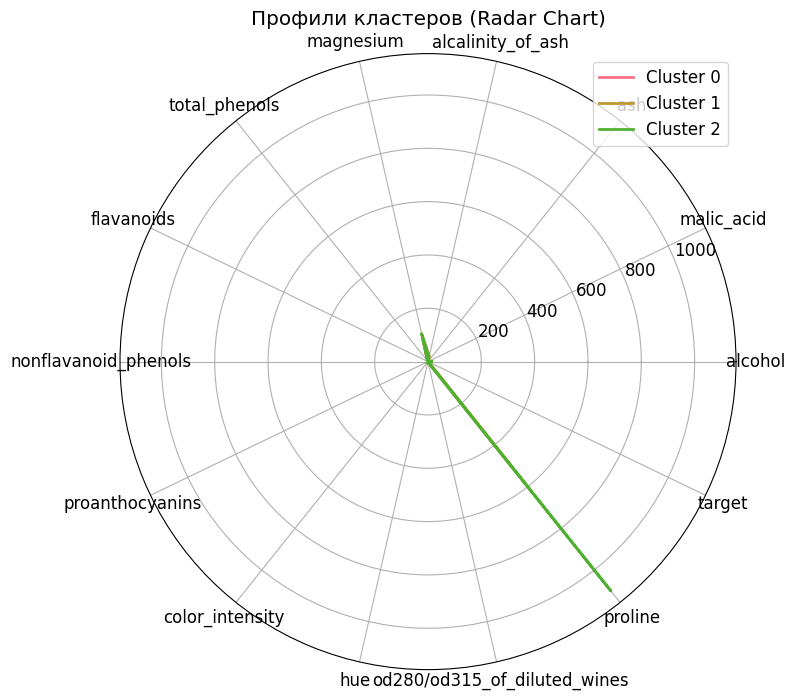

In [ ]:
# ЗАДАЧА 8.2: Интерпретация кластеров
from math import pi
labels = labels_km

df_clusters = df.copy()
df_clusters['cluster'] = labels

cluster_means = df_clusters.groupby('cluster').mean()
print("Сред. значения признаков по кластерам:")
print(cluster_means)

plt.figure(figsize=(10,6))
sns.heatmap(cluster_means, annot=True, cmap='coolwarm')
plt.title("Сред. значения признаков по кластерам")
plt.show()

categories = list(cluster_means.columns)
N = len(categories)

angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

plt.figure(figsize=(8,8))
for i, row in cluster_means.iterrows():
    values = row.tolist()
    values += values[:1]
    plt.polar(angles, values, label=f'Cluster {i}', linewidth=2)
plt.xticks(angles[:-1], categories, rotation=45)
plt.title("Профили кластеров (Radar Chart)")
plt.legend(loc='upper right')
plt.show()